# Predicción del Rendimiento Académico según Hábitos de Estudio y Videojuegos

**Universidad Galileo**

**Postgrado de Inteligencia Artificial**

Manejo de Datos para la IA

**Dataset:** Gaming vs Academic Performance (Kaggle)

---

Este proyecto tiene dos componentes:

1. **Predicción (Regresión):** predecir la nota final (`grades`) a partir de los hábitos de estudio y entretenimiento del estudiante.
2. **Análisis de efectos:** evaluar el impacto de los hábitos de videojuegos sobre el rendimiento académico.

**Tipo de problema:** Regresión, porque la variable objetivo `grades` es continua.

# Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Dataset

In [2]:
!pip install kagglehub

import kagglehub
from kagglehub import KaggleDatasetAdapter

file_path = "Gaming_Academic_Performance.csv"

raw_dataset = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "nalisha/gaming-vs-academic-performance",
  file_path,
)

/tmp/ipykernel_10882/904799194.py:8: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  raw_dataset = kagglehub.load_dataset(


100%|██████████| 593k/593k [00:00<00:00, 2.52MB/s]


# Exploracion del Dataset

In [3]:
raw_dataset.head()

,student_id,age,gender,gaming_hours,study_hours,sleep_hours,attendance,gaming_genre,social_activity,device_usage,reaction_time_ms,addiction_score,stress_level,grades
0,1,22,Male,7.23,8.78,6.96,91.44,FPS,3.25,9.36,235.84,14.69,Low,86.459555
1,2,19,Male,0.07,8.72,7.63,63.63,Casual,1.02,3.21,328.71,2.47,Medium,98.230000
2,3,23,Female,1.73,9.56,4.40,83.26,Casual,3.46,5.56,313.61,4.73,High,90.560000
3,4,20,Female,6.62,1.68,7.83,75.04,RPG,1.46,11.78,241.84,14.54,Low,32.670000
4,5,22,Female,5.36,5.83,5.55,65.57,FPS,1.01,8.23,249.31,12.48,Low,58.710000


## Tipos de las Columnas

In [4]:
datatype_counts = raw_dataset.dtypes.value_counts()
datatype_counts

,count
float64,9
object,3
int64,2


In [5]:
numeric_cols = raw_dataset.select_dtypes(include=['number']).columns.tolist()
numeric_cols

['student_id',
 'age',
 'gaming_hours',
 'study_hours',
 'sleep_hours',
 'attendance',
 'social_activity',
 'device_usage',
 'reaction_time_ms',
 'addiction_score',
 'grades']

In [6]:
categorical_cols = raw_dataset.select_dtypes(include=['object', 'bool']).columns.tolist()
categorical_cols

['gender', 'gaming_genre', 'stress_level']

In [7]:
raw_dataset.describe()

,student_id,age,gaming_hours,study_hours,sleep_hours,attendance,social_activity,device_usage,reaction_time_ms,addiction_score,grades
count,8000.00000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000
mean,4000.50000,19.983625,4.085773,5.460581,6.493453,79.886525,2.507790,7.586315,271.105839,9.908492,66.180776
std,2309.54541,2.587072,2.308801,2.575787,1.442656,11.580419,1.441128,2.710035,29.440675,5.035837,22.422024
min,1.00000,16.000000,0.000000,1.000000,4.000000,60.000000,0.000000,1.100000,183.260000,-4.510000,0.000000
25%,2000.75000,18.000000,2.130000,3.240000,5.240000,69.780000,1.287500,5.560000,247.160000,5.920000,49.879843
50%,4000.50000,20.000000,4.130000,5.460000,6.505000,79.695000,2.500000,7.610000,270.475000,10.005000,67.070000
75%,6000.25000,22.000000,6.060000,7.660000,7.730000,90.100000,3.760000,9.600000,294.690000,13.860000,83.992223
max,8000.00000,24.000000,8.000000,10.000000,9.000000,100.000000,5.000000,13.950000,347.870000,23.160000,118.632936


## Valores Nulos

In [8]:
missing_values = raw_dataset.isnull().sum()
print(missing_values[missing_values > 0])

Series([], dtype: int64)


No hay valores nulos, por lo tanto no hay nada mas que hacer.

## Distribución de la variable objetivo

Como el problema es de regresión observamos la distribución de la variable objetivo `grades`.

count    8000.000000
mean       66.180776
std        22.422024
min         0.000000
25%        49.879843
50%        67.070000
75%        83.992223
max       118.632936
Name: grades, dtype: float64


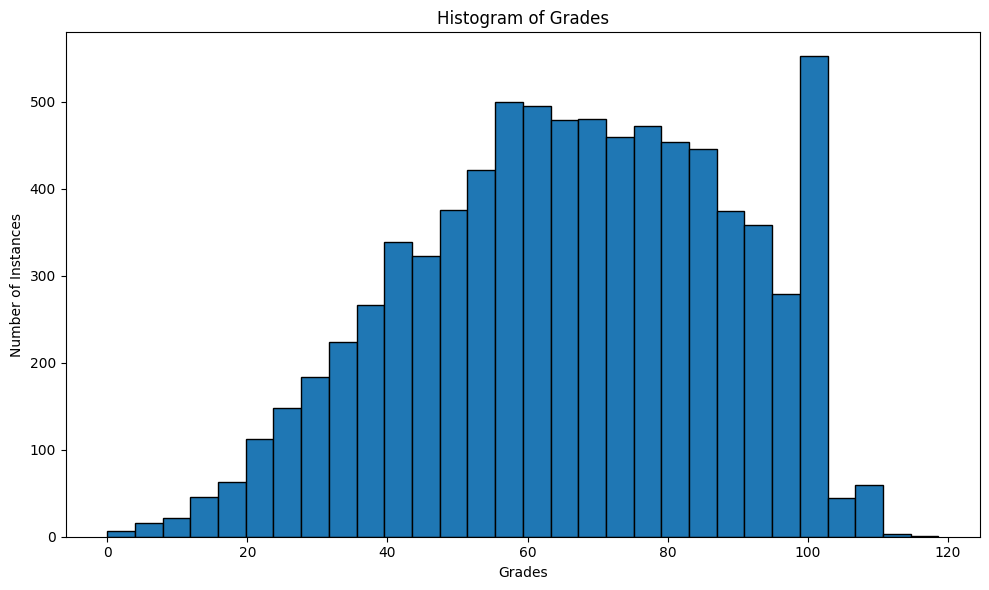

In [9]:
print(raw_dataset['grades'].describe())

plt.figure(figsize=(10, 6))
plt.hist(raw_dataset['grades'], bins=30, edgecolor='black')
plt.xlabel('Grades')
plt.ylabel('Number of Instances')
plt.title('Histogram of Grades')
plt.tight_layout()
plt.show()

Podemos ver una distribución con una curva bastante estandar, excepto en el rango de 100%. En las notas de 100% se observa una cantidad alta de instancias. Esto tiene sentido con la realidad dado que para la mayoria de los cursos, 100% es la nota maxima. En donde la curva seguiria decreciendo hasta alrededor de 200%, el corte causa que se acumulen en el 100%.

# Procesar Anomalias

Antes de modelar, revisamos si existen valores atípicos (anomalías) en las variables numéricas principales. Aplicamos las mismas técnicas vistas en el laboratorio: método estadístico (Z-score), Isolation Forest y One-Class SVM.

In [10]:
anomaly_dataset = raw_dataset.copy()
print(anomaly_dataset.isnull().sum())
print(anomaly_dataset.shape)

student_id          0
age                 0
gender              0
gaming_hours        0
study_hours         0
sleep_hours         0
attendance          0
gaming_genre        0
social_activity     0
device_usage        0
reaction_time_ms    0
addiction_score     0
stress_level        0
grades              0
dtype: int64
(8000, 14)


## Statistic Method (Desviación estándar)

Detectamos como anomalías los valores que se alejan más de 3 desviaciones estándar de la media. Aplicamos sobre `gaming_hours`.


Original dataset shape: (8000, 14)
Cleaned dataset shape: (8000, 14)


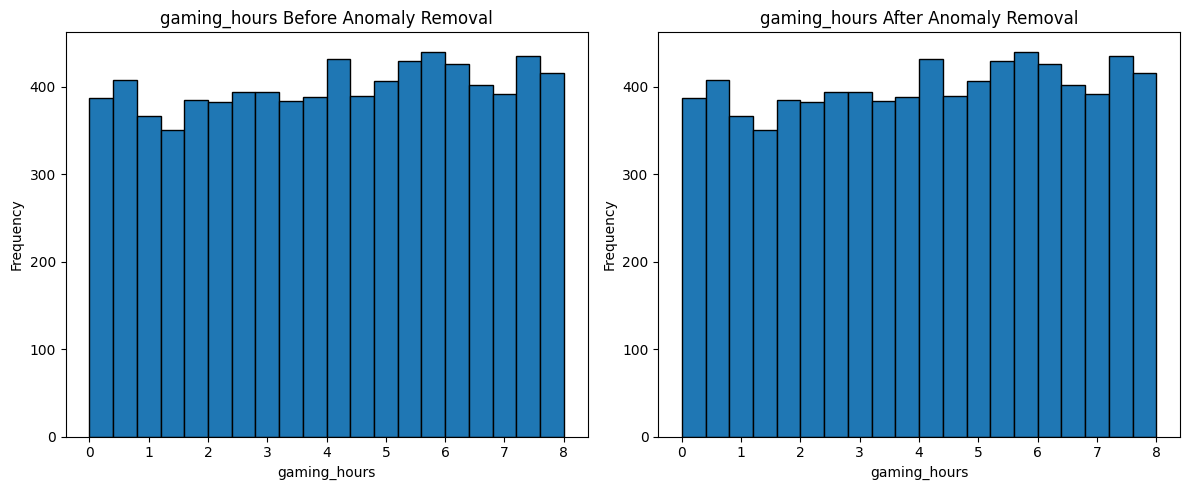

In [11]:
variable = 'gaming_hours'

mean_val = anomaly_dataset[variable].mean()
std_val = anomaly_dataset[variable].std()

threshold = 3

anomalies_mask = (anomaly_dataset[variable] > mean_val + threshold * std_val) | (anomaly_dataset[variable] < mean_val - threshold * std_val)

anomaly_dataset_cleaned = anomaly_dataset[~anomalies_mask].copy()

print("\nOriginal dataset shape:", anomaly_dataset.shape)
print("Cleaned dataset shape:", anomaly_dataset_cleaned.shape)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(anomaly_dataset[variable], bins=20, edgecolor='black')
plt.title(f'{variable} Before Anomaly Removal')
plt.xlabel(variable)
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
plt.hist(anomaly_dataset_cleaned[variable], bins=20, edgecolor='black')
plt.title(f'{variable} After Anomaly Removal')
plt.xlabel(variable)
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

## Z-Score Scaling

Usando la función `zscore` de scipy.

In [12]:
from scipy.stats import zscore

anomaly_dataset['gaming_zscore'] = zscore(anomaly_dataset['gaming_hours'])

zscore_threshold = 3

anomalies_mask_zscore = (anomaly_dataset['gaming_zscore'] > zscore_threshold) | (anomaly_dataset['gaming_zscore'] < -zscore_threshold)

anomaly_dataset_cleaned_zscore = anomaly_dataset[~anomalies_mask_zscore].copy()

print("\nOriginal dataset shape:", anomaly_dataset.shape)
print("Cleaned dataset shape (Z-score):", anomaly_dataset_cleaned_zscore.shape)


Original dataset shape: (8000, 15)
Cleaned dataset shape (Z-score): (8000, 15)


## Isolation Forest

In [13]:
from sklearn.ensemble import IsolationForest

X_iso = anomaly_dataset[['gaming_hours', 'study_hours', 'sleep_hours', 'grades']].values

iso_forest = IsolationForest(n_estimators=100, random_state=42, contamination=0.01)

outliers = iso_forest.fit_predict(X_iso)

anomaly_dataset['is_outlier_isoforest'] = outliers

anomaly_dataset_cleaned_isoforest = anomaly_dataset[anomaly_dataset['is_outlier_isoforest'] == 1].copy()

print("\nOriginal dataset shape:", anomaly_dataset.shape)
print("Cleaned dataset shape (Isolation Forest):", anomaly_dataset_cleaned_isoforest.shape)
print("Number of anomalies detected by Isolation Forest:", (anomaly_dataset['is_outlier_isoforest'] == -1).sum())


Original dataset shape: (8000, 16)
Cleaned dataset shape (Isolation Forest): (7920, 16)
Number of anomalies detected by Isolation Forest: 80


# Pre-Procesamiento
Preparamos los datos para el modelo: codificamos las variables categóricas y separamos las variables numéricas que escalaremos.

In [14]:
processing_dataset = raw_dataset.copy()

# Eliminamos el identificador, no aporta a la predicción
if 'student_id' in processing_dataset.columns:
    processing_dataset = processing_dataset.drop(columns=['student_id'])

processing_dataset.head()

,age,gender,gaming_hours,study_hours,sleep_hours,attendance,gaming_genre,social_activity,device_usage,reaction_time_ms,addiction_score,stress_level,grades
0,22,Male,7.23,8.78,6.96,91.44,FPS,3.25,9.36,235.84,14.69,Low,86.459555
1,19,Male,0.07,8.72,7.63,63.63,Casual,1.02,3.21,328.71,2.47,Medium,98.230000
2,23,Female,1.73,9.56,4.40,83.26,Casual,3.46,5.56,313.61,4.73,High,90.560000
3,20,Female,6.62,1.68,7.83,75.04,RPG,1.46,11.78,241.84,14.54,Low,32.670000
4,22,Female,5.36,5.83,5.55,65.57,FPS,1.01,8.23,249.31,12.48,Low,58.710000


### Ordinal Encoding

`stress_level` tiene un orden natural (Low < Medium < High), por lo que usamos un mapeo ordinal.

In [15]:
stress_level_mapping = {
    "Low": 0,
    "Medium": 1,
    "High": 2
}

processing_dataset['stress_level'] = processing_dataset['stress_level'].map(stress_level_mapping)
processing_dataset.head()

,age,gender,gaming_hours,study_hours,sleep_hours,attendance,gaming_genre,social_activity,device_usage,reaction_time_ms,addiction_score,stress_level,grades
0,22,Male,7.23,8.78,6.96,91.44,FPS,3.25,9.36,235.84,14.69,0,86.459555
1,19,Male,0.07,8.72,7.63,63.63,Casual,1.02,3.21,328.71,2.47,1,98.230000
2,23,Female,1.73,9.56,4.40,83.26,Casual,3.46,5.56,313.61,4.73,2,90.560000
3,20,Female,6.62,1.68,7.83,75.04,RPG,1.46,11.78,241.84,14.54,0,32.670000
4,22,Female,5.36,5.83,5.55,65.57,FPS,1.01,8.23,249.31,12.48,0,58.710000


### One Hot Encoding

`gaming_genre` (FPS, RPG, Casual, ...) no tiene orden, por lo que aplicamos One-Hot Encoding.

`gender` (Male, Female, Other) la inclusión de Other hace que gender deje de ser binario, por lo tanto es necesario One Hot Encoding.

In [16]:
from sklearn.preprocessing import OneHotEncoder

enc = OneHotEncoder(handle_unknown='ignore')

enc.fit(processing_dataset[['gaming_genre']])

onehotlabels = enc.transform(processing_dataset[['gaming_genre']]).toarray()

onehotlabels_dataset = pd.DataFrame(onehotlabels, columns=enc.get_feature_names_out(['gaming_genre']))
onehotlabels_dataset.head()

,gaming_genre_Casual,gaming_genre_FPS,gaming_genre_RPG
0,0.0,1.0,0.0
1,1.0,0.0,0.0
2,1.0,0.0,0.0
3,0.0,0.0,1.0
4,0.0,1.0,0.0


In [17]:
processing_dataset = processing_dataset.reset_index(drop=True)
processing_dataset = pd.concat([processing_dataset.drop(columns=['gaming_genre']), onehotlabels_dataset], axis=1)
processing_dataset.head()

,age,gender,gaming_hours,study_hours,sleep_hours,attendance,social_activity,device_usage,reaction_time_ms,addiction_score,stress_level,grades,gaming_genre_Casual,gaming_genre_FPS,gaming_genre_RPG
0,22,Male,7.23,8.78,6.96,91.44,3.25,9.36,235.84,14.69,0,86.459555,0.0,1.0,0.0
1,19,Male,0.07,8.72,7.63,63.63,1.02,3.21,328.71,2.47,1,98.230000,1.0,0.0,0.0
2,23,Female,1.73,9.56,4.40,83.26,3.46,5.56,313.61,4.73,2,90.560000,1.0,0.0,0.0
3,20,Female,6.62,1.68,7.83,75.04,1.46,11.78,241.84,14.54,0,32.670000,0.0,0.0,1.0
4,22,Female,5.36,5.83,5.55,65.57,1.01,8.23,249.31,12.48,0,58.710000,0.0,1.0,0.0


In [18]:
enc_gender = OneHotEncoder(handle_unknown='ignore')
enc_gender.fit(processing_dataset[['gender']])

onehotlabels_gender = enc_gender.transform(processing_dataset[['gender']]).toarray()
onehotlabels_gender_dataset = pd.DataFrame(onehotlabels_gender, columns=enc_gender.get_feature_names_out(['gender']))

processing_dataset = pd.concat([processing_dataset.drop(columns=['gender']), onehotlabels_gender_dataset], axis=1)
processing_dataset.head()

,age,gaming_hours,study_hours,sleep_hours,attendance,social_activity,device_usage,reaction_time_ms,addiction_score,stress_level,grades,gaming_genre_Casual,gaming_genre_FPS,gaming_genre_RPG,gender_Female,gender_Male,gender_Other
0,22,7.23,8.78,6.96,91.44,3.25,9.36,235.84,14.69,0,86.459555,0.0,1.0,0.0,0.0,1.0,0.0
1,19,0.07,8.72,7.63,63.63,1.02,3.21,328.71,2.47,1,98.230000,1.0,0.0,0.0,0.0,1.0,0.0
2,23,1.73,9.56,4.40,83.26,3.46,5.56,313.61,4.73,2,90.560000,1.0,0.0,0.0,1.0,0.0,0.0
3,20,6.62,1.68,7.83,75.04,1.46,11.78,241.84,14.54,0,32.670000,0.0,0.0,1.0,1.0,0.0,0.0
4,22,5.36,5.83,5.55,65.57,1.01,8.23,249.31,12.48,0,58.710000,0.0,1.0,0.0,1.0,0.0,0.0


## Scaling

### Z-Score Normalization

Escalamos las variables numéricas continuas con `StandardScaler`.

In [19]:
from sklearn.preprocessing import StandardScaler

cols_to_normalize = ['age', 'gaming_hours', 'study_hours', 'sleep_hours',
                     'attendance', 'social_activity', 'device_usage',
                     'reaction_time_ms', 'addiction_score']

scaler = StandardScaler()
processing_dataset[cols_to_normalize] = scaler.fit_transform(processing_dataset[cols_to_normalize])

processing_dataset.head()

,age,gaming_hours,study_hours,sleep_hours,attendance,social_activity,device_usage,reaction_time_ms,addiction_score,stress_level,grades,gaming_genre_Casual,gaming_genre_FPS,gaming_genre_RPG,gender_Female,gender_Male,gender_Other
0,0.779453,1.361929,1.288781,0.323415,0.997736,0.515052,0.654529,-1.197936,0.949555,0,86.459555,0.0,1.0,0.0,0.0,1.0,0.0
1,-0.380232,-1.739441,1.265486,0.787865,-1.403882,-1.032443,-1.614956,1.956741,-1.477204,1,98.230000,1.0,0.0,0.0,0.0,1.0,0.0
2,1.166014,-1.020408,1.591620,-1.451201,0.291327,0.660781,-0.747755,1.443813,-1.028392,2,90.560000,1.0,0.0,0.0,1.0,0.0,0.0
3,0.006330,1.097707,-1.467830,0.926507,-0.418536,-0.727108,1.547562,-0.994124,0.919767,0,32.670000,0.0,0.0,1.0,1.0,0.0,0.0
4,0.779453,0.551935,0.143429,-0.654010,-1.236347,-1.039383,0.237534,-0.740377,0.510673,0,58.710000,0.0,1.0,0.0,1.0,0.0,0.0


# Analisis Exploratorio

Análisis exploratorio para entender las relaciones entre las variables y, en particular, el efecto de los videojuegos sobre la nota.

In [20]:
eda_dataset = raw_dataset.copy()
if 'student_id' in eda_dataset.columns:
    eda_dataset = eda_dataset.drop(columns=['student_id'])
print(eda_dataset.shape)

(8000, 13)


## Correlation Matrix

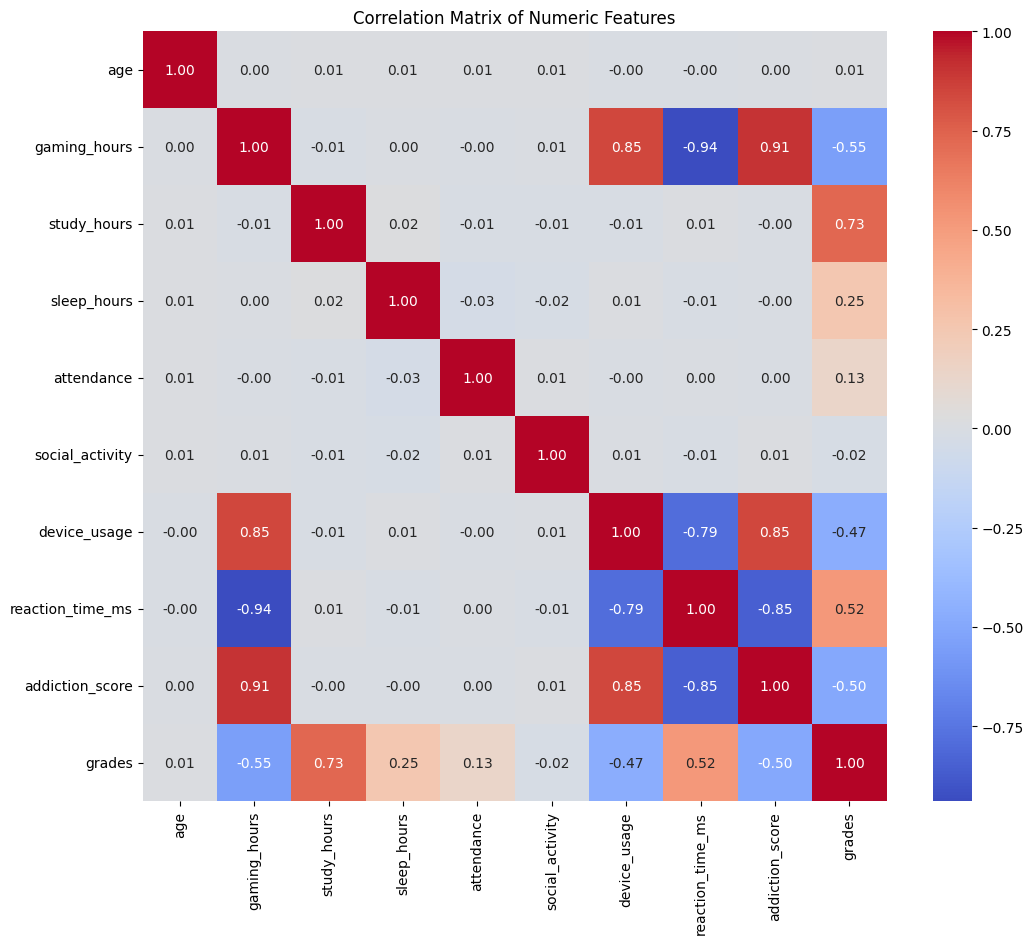

In [21]:
numeric_eda_cols = eda_dataset.select_dtypes(include=np.number)
correlation_matrix = numeric_eda_cols.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numeric Features')
plt.show()

In [22]:
# Correlación de cada variable con la nota
print(correlation_matrix['grades'].sort_values(ascending=False))

grades              1.000000
study_hours         0.733132
reaction_time_ms    0.517340
sleep_hours         0.250298
attendance          0.130842
age                 0.008052
social_activity    -0.018717
device_usage       -0.468472
addiction_score    -0.495055
gaming_hours       -0.551312
Name: grades, dtype: float64


## Efecto de los Videojuegos sobre la Nota

Visualizamos directamente la relación entre horas de videojuego y la nota, y cómo influye el balance con las horas de estudio.

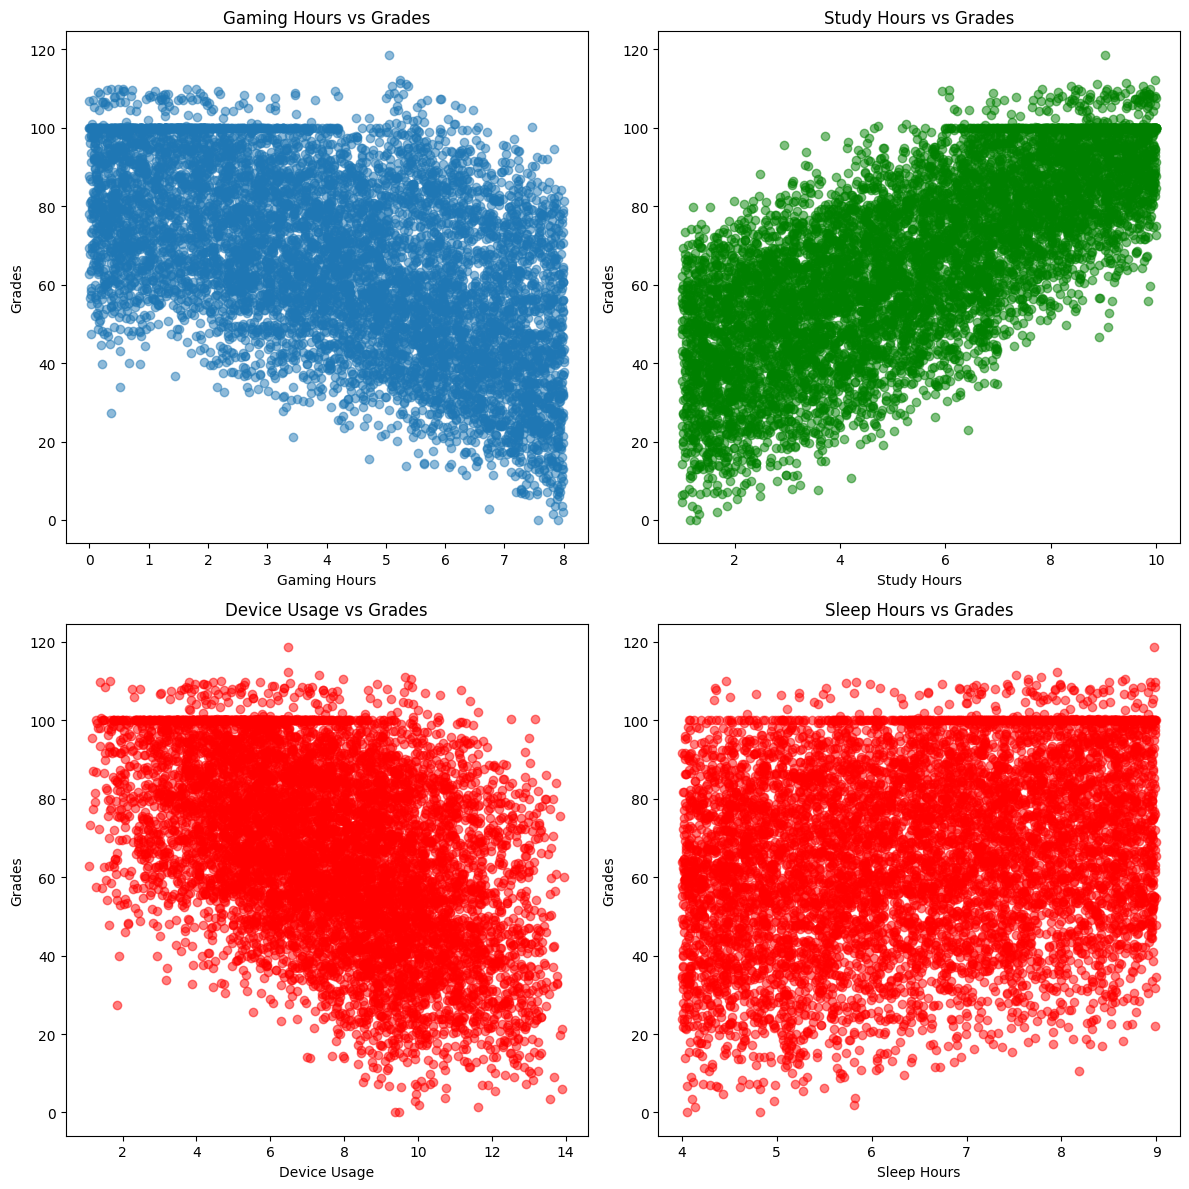

In [23]:
plt.figure(figsize=(12, 12))

plt.subplot(2, 2, 1)
plt.scatter(eda_dataset['gaming_hours'], eda_dataset['grades'], alpha=0.5)
plt.title('Gaming Hours vs Grades')
plt.xlabel('Gaming Hours')
plt.ylabel('Grades')

plt.subplot(2, 2, 2)
plt.scatter(eda_dataset['study_hours'], eda_dataset['grades'], alpha=0.5, color='green')
plt.title('Study Hours vs Grades')
plt.xlabel('Study Hours')
plt.ylabel('Grades')

plt.subplot(2, 2, 3)
plt.scatter(eda_dataset['device_usage'], eda_dataset['grades'], alpha=0.5, color='red')
plt.title('Device Usage vs Grades')
plt.xlabel('Device Usage')
plt.ylabel('Grades')

plt.subplot(2, 2, 4)
plt.scatter(eda_dataset['sleep_hours'], eda_dataset['grades'], alpha=0.5, color='red')
plt.title('Sleep Hours vs Grades')
plt.xlabel('Sleep Hours')
plt.ylabel('Grades')

plt.tight_layout()
plt.show()

# Modelado Predictivo (Regresión)

Separamos en entrenamiento (70%), validación (15%) y prueba (15%). Entrenamos cuatro modelos y comparamos su desempeño con R², RMSE, MAE y MAPE.


In [24]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

X = processing_dataset.drop(columns=['grades'])
y = processing_dataset['grades']

# Split: 70% train, 15% validación, 15% test
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42)

print('Entrenamiento:', X_train.shape, '| Validación:', X_val.shape, '| Prueba:', X_test.shape)


Entrenamiento: (5600, 16) | Validación: (1200, 16) | Prueba: (1200, 16)


## Regresión Lineal (modelo base)

In [25]:
lin = LinearRegression()
lin.fit(X_train, y_train)
pred_lin = lin.predict(X_test)

print("Regresión Lineal")
print("R2:  ", round(r2_score(y_test, pred_lin), 3))
print("RMSE:", round(np.sqrt(mean_squared_error(y_test, pred_lin)), 3))
print("MAE: ", round(mean_absolute_error(y_test, pred_lin), 3))

Regresión Lineal
R2:   0.898
RMSE: 7.046
MAE:  5.568


## XGBoost (Gradient Boosting)

Modelo de gradiente potenciado, generalmente supera a Random Forest en datasets tabulares.


In [26]:
from xgboost import XGBRegressor

xgb = XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=5, random_state=42, verbosity=0)
xgb.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
pred_xgb = xgb.predict(X_test)

print('XGBoost')
print('R2:  ', round(r2_score(y_test, pred_xgb), 3))
print('RMSE:', round(np.sqrt(mean_squared_error(y_test, pred_xgb)), 3))
print('MAE: ', round(mean_absolute_error(y_test, pred_xgb), 3))


XGBoost
R2:   0.926
RMSE: 5.995
MAE:  4.699


## Random Forest

In [27]:
rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

print("Random Forest")
print("R2:  ", round(r2_score(y_test, pred_rf), 3))
print("RMSE:", round(np.sqrt(mean_squared_error(y_test, pred_rf)), 3))
print("MAE: ", round(mean_absolute_error(y_test, pred_rf), 3))


Random Forest
R2:   0.922
RMSE: 6.194
MAE:  4.827


K-Nearest Neighbors

In [28]:
from sklearn.neighbors import KNeighborsRegressor

knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train, y_train)
pred_knn = knn.predict(X_test)

print("KNN")
print("R2:  ", round(r2_score(y_test, pred_knn), 3))
print("RMSE:", round(np.sqrt(mean_squared_error(y_test, pred_knn)), 3))
print("MAE: ", round(mean_absolute_error(y_test, pred_knn), 3))

KNN
R2:   0.841
RMSE: 8.826
MAE:  6.982


## Importancia de las Variables

Qué hábitos pesan más en la predicción de la nota.

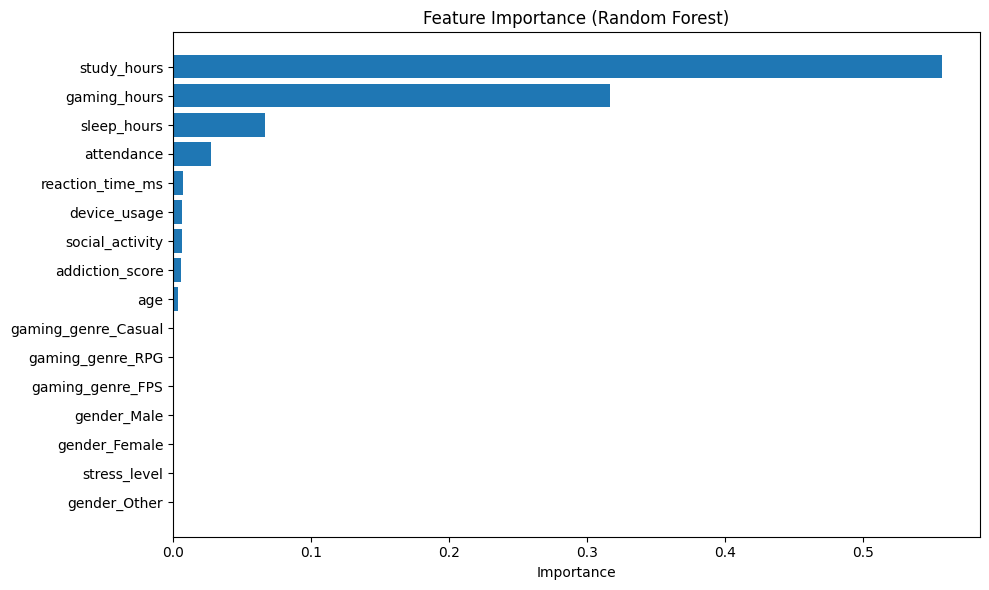

study_hours            0.556903
gaming_hours           0.316715
sleep_hours            0.066254
attendance             0.027191
reaction_time_ms       0.006817
device_usage           0.006151
social_activity        0.006127
addiction_score        0.006001
age                    0.003643
gaming_genre_Casual    0.000758
gaming_genre_RPG       0.000740
gaming_genre_FPS       0.000706
gender_Male            0.000650
gender_Female          0.000611
stress_level           0.000501
gender_Other           0.000232
dtype: float64


In [29]:
importancias = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(importancias.index[::-1], importancias.values[::-1])
plt.title('Feature Importance (Random Forest)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

print(importancias)

## Predicciones vs Valores Reales

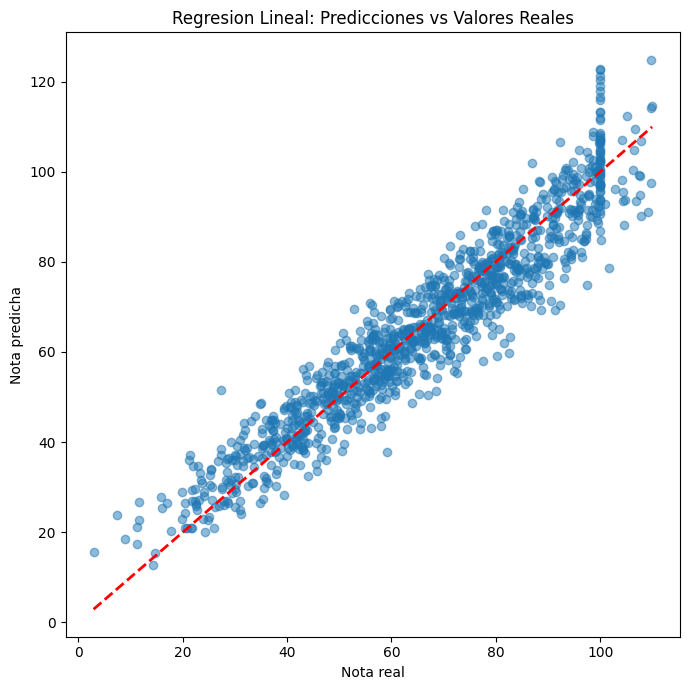

In [30]:
plt.figure(figsize=(7, 7))
plt.scatter(y_test, pred_lin, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Nota real')
plt.ylabel('Nota predicha')
plt.title('Regresion Lineal: Predicciones vs Valores Reales')
plt.tight_layout()
plt.show()

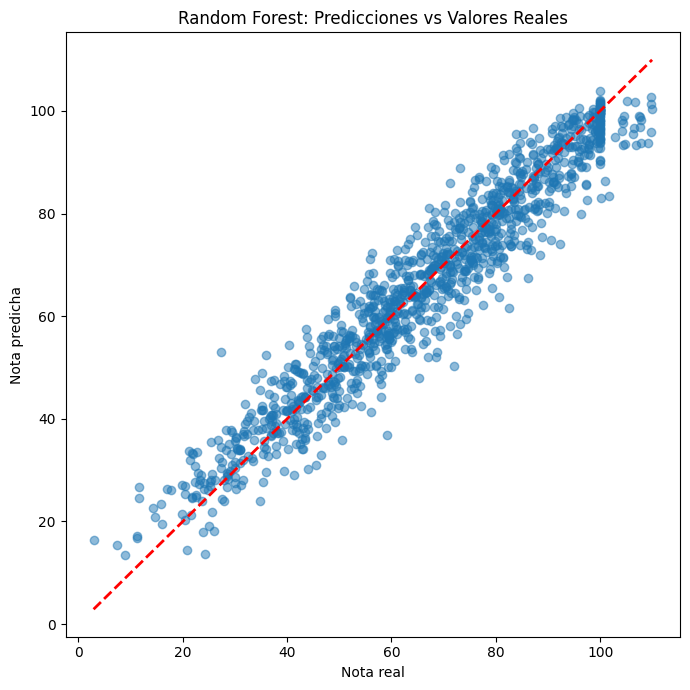

In [31]:
plt.figure(figsize=(7, 7))
plt.scatter(y_test, pred_rf, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Nota real')
plt.ylabel('Nota predicha')
plt.title('Random Forest: Predicciones vs Valores Reales')
plt.tight_layout()
plt.show()

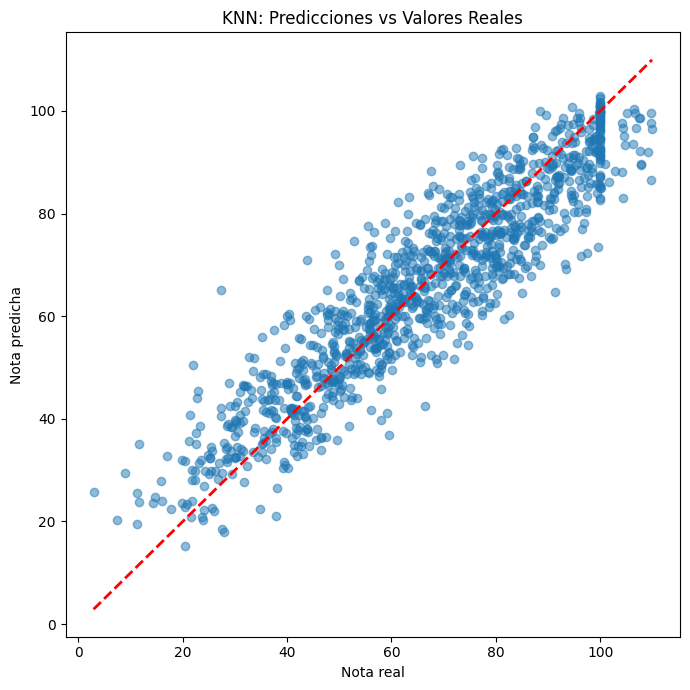

In [32]:
plt.figure(figsize=(7, 7))
plt.scatter(y_test, pred_knn, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Nota real')
plt.ylabel('Nota predicha')
plt.title('KNN: Predicciones vs Valores Reales')
plt.tight_layout()
plt.show()

# Ajuste de Hiperparámetros (Random Search)

Usamos `RandomizedSearchCV` para buscar los mejores hiperparámetros de Random Forest y XGBoost, evaluando con validación cruzada sobre el conjunto de entrenamiento.


In [33]:
from sklearn.model_selection import RandomizedSearchCV
import scipy.stats as scipy_stats

# --- Random Forest ---
param_dist_rf = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [None, 5, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None]
}

rf_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42),
    param_distributions=param_dist_rf,
    n_iter=20, cv=5, scoring='r2', random_state=42, n_jobs=-1
)
rf_search.fit(X_train, y_train)
best_rf = rf_search.best_estimator_
pred_rf_tuned = best_rf.predict(X_test)

print('Best RF params:', rf_search.best_params_)
print('RF Tuned  R2:  ', round(r2_score(y_test, pred_rf_tuned), 3))
print('RF Tuned  RMSE:', round(np.sqrt(mean_squared_error(y_test, pred_rf_tuned)), 3))
print('RF Tuned  MAE: ', round(mean_absolute_error(y_test, pred_rf_tuned), 3))


Best RF params: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': None, 'max_depth': None}
RF Tuned  R2:   0.921
RF Tuned  RMSE: 6.2
RF Tuned  MAE:  4.829


In [34]:
# --- XGBoost ---
param_dist_xgb = {
    'n_estimators': [100, 200, 300, 500],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7, 9],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0]
}

xgb_search = RandomizedSearchCV(
    XGBRegressor(random_state=42, verbosity=0),
    param_distributions=param_dist_xgb,
    n_iter=20, cv=5, scoring='r2', random_state=42, n_jobs=-1
)
xgb_search.fit(X_train, y_train)
best_xgb = xgb_search.best_estimator_
pred_xgb_tuned = best_xgb.predict(X_test)

print('Best XGB params:', xgb_search.best_params_)
print('XGB Tuned  R2:  ', round(r2_score(y_test, pred_xgb_tuned), 3))
print('XGB Tuned  RMSE:', round(np.sqrt(mean_squared_error(y_test, pred_xgb_tuned)), 3))
print('XGB Tuned  MAE: ', round(mean_absolute_error(y_test, pred_xgb_tuned), 3))


Best XGB params: {'subsample': 0.8, 'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.05, 'colsample_bytree': 0.6}
XGB Tuned  R2:   0.925
XGB Tuned  RMSE: 6.053
XGB Tuned  MAE:  4.792


# Ensemble: Combinación Ponderada de Modelos

Combinamos los cuatro modelos asignando a cada uno un peso proporcional a su R². Esto reduce la influencia de los modelos más débiles (KNN) y amplifica la de los mejores (XGBoost, Random Forest), con el objetivo de superar a los modelos individuales.


Pesos  →  XGB: 0.258 | RF: 0.257 | Lin: 0.251 | KNN: 0.234
Ensemble (ponderado por R²)
R2:   0.918
RMSE: 6.33
MAE:  5.011


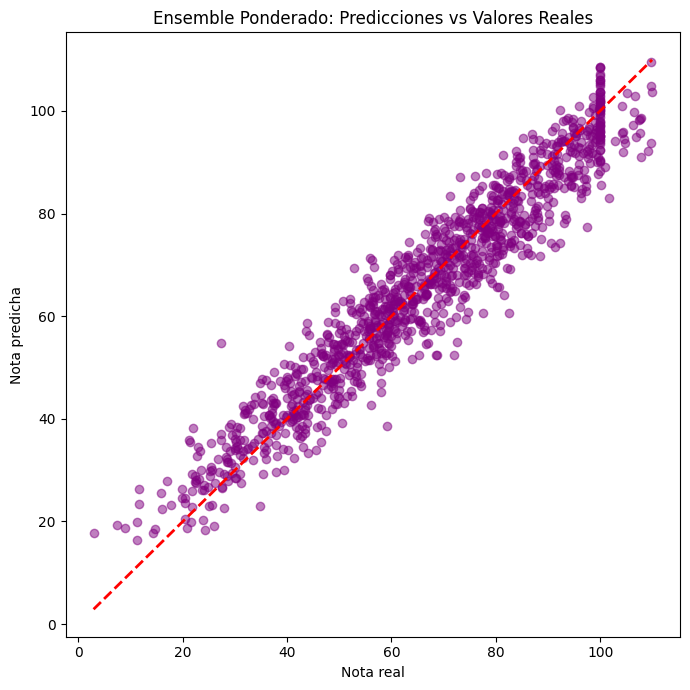

In [35]:
# Ensemble ponderado: pesos proporcionales al R² de cada modelo
# R²: XGB=0.925, RF=0.921, Lin=0.898, KNN=0.841
r2_xgb  = r2_score(y_test, pred_xgb_tuned)
r2_rf   = r2_score(y_test, pred_rf_tuned)
r2_lin  = r2_score(y_test, pred_lin)
r2_knn  = r2_score(y_test, pred_knn)
total_r2 = r2_xgb + r2_rf + r2_lin + r2_knn

w_xgb = r2_xgb / total_r2
w_rf  = r2_rf  / total_r2
w_lin = r2_lin / total_r2
w_knn = r2_knn / total_r2

print(f'Pesos  →  XGB: {w_xgb:.3f} | RF: {w_rf:.3f} | Lin: {w_lin:.3f} | KNN: {w_knn:.3f}')

pred_ensemble = w_xgb * pred_xgb_tuned + w_rf * pred_rf_tuned + w_lin * pred_lin + w_knn * pred_knn

print('Ensemble (ponderado por R²)')
print('R2:  ', round(r2_score(y_test, pred_ensemble), 3))
print('RMSE:', round(np.sqrt(mean_squared_error(y_test, pred_ensemble)), 3))
print('MAE: ', round(mean_absolute_error(y_test, pred_ensemble), 3))

plt.figure(figsize=(7, 7))
plt.scatter(y_test, pred_ensemble, alpha=0.5, color='purple')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Nota real')
plt.ylabel('Nota predicha')
plt.title('Ensemble Ponderado: Predicciones vs Valores Reales')
plt.tight_layout()
plt.show()


# Comparación de Métricas

Tabla comparativa de todos los modelos con R², RMSE, MAE y MAPE. Adicionalmente, se aplica un test ANOVA para evaluar si hay diferencia estadística significativa entre los errores de cada modelo.


In [36]:
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

def mape(y_true, y_pred):
    y_true = np.array(y_true)
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

models = {
    'Linear Regression': pred_lin,
    'Random Forest (tuned)': pred_rf_tuned,
    'KNN': pred_knn,
    'XGBoost (tuned)': pred_xgb_tuned,
    'Ensemble': pred_ensemble
}

rows = []
errors = {}
for name, pred in models.items():
    r2 = r2_score(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    mae = mean_absolute_error(y_test, pred)
    _mape = mape(y_test, pred)
    rows.append({'Modelo': name, 'R2': round(r2, 4), 'RMSE': round(rmse, 4), 'MAE': round(mae, 4), 'MAPE (%)': round(_mape, 2)})
    errors[name] = np.abs(np.array(y_test) - np.array(pred))

metrics_df = pd.DataFrame(rows).sort_values('R2', ascending=False)
print(metrics_df.to_string(index=False))

# ANOVA entre los errores absolutos de cada modelo
f_stat, p_val = stats.f_oneway(*errors.values())
print(f'\nANOVA sobre errores absolutos: F={f_stat:.4f}, p={p_val:.4f}')
if p_val < 0.05:
    print('  → Diferencia estadísticamente significativa entre modelos (p < 0.05)')
else:
    print('  → No hay diferencia significativa entre modelos (p >= 0.05)')


               Modelo     R2   RMSE    MAE  MAPE (%)
      XGBoost (tuned) 0.9251 6.0532 4.7918      8.83
Random Forest (tuned) 0.9214 6.2002 4.8288      9.26
             Ensemble 0.9180 6.3298 5.0113      9.55
    Linear Regression 0.8984 7.0462 5.5676     10.20
                  KNN 0.8407 8.8257 6.9815     13.62

ANOVA sobre errores absolutos: F=55.1629, p=0.0000
  → Diferencia estadísticamente significativa entre modelos (p < 0.05)
